In [12]:
"""
SafeFam — 음성(STT) 피싱 탐지 베이즈 분류기 학습 스크립트
===========================================================
Author : Backend B (기범)
Dataset: metadata_clean.csv (1,413건 / train=974, val=221, test=218)
Based on: train_v2.py (SMS 분류기)

SMS 대비 주요 차이점:
  - 입력: 구어체 STT 텍스트 (text_clean 컬럼, 전처리 완료본)
  - split: 메타데이터 split 컬럼 그대로 사용 (train/validation/test 3분할)
  - 튜닝: validation으로 alpha/threshold 탐색, test는 최종 평가 전용
  - 벡터화: char n-gram vs word n-gram 비교 후 최적 선택
  - 클래스 불균형: normal(653) < phishing(760) → class_prior 보정

탐지 파이프라인 내 위치:
  음성 통화 → STT 변환 → text_clean 정규화 → 이 모델 → risk_score
  (SMS 파이프라인과 별도 모델로 운영)

저장 파일:
  voice_model_artifact.pkl  — model + threshold + classes + vectorizer_type
  voice_vectorizer.pkl      — 학습된 벡터라이저
"""

from __future__ import annotations

import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import ComplementNB, MultinomialNB

warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────────────────────────────────────
# 상수
# ─────────────────────────────────────────────────────────────────────────────

DATA_PATH       = Path("../Data/CallData/metadata_clean.csv")
MODEL_PATH      = Path("voice_model_artifact.pkl")    # model + threshold + classes + vec_type
VECTORIZER_PATH = Path("voice_vectorizer.pkl")

RANDOM_STATE           = 42
TARGET_PHISHING_RECALL = 0.85   # 피싱 미탐(FN) > 정상 오탐(FP)

# risk_level 구간 (SMS와 동일 기준)
RISK_HIGH_THRESHOLD   = 70    # HIGH   : 70점 이상

RISK_MEDIUM_THRESHOLD = 40    # MEDIUM : 40~69점 (LLM 에스컬레이션 대상)
                               # LOW    : 40점 미만

# 격자 탐색 범위
ALPHA_GRID     = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]
THRESHOLD_GRID = np.round(np.arange(0.30, 0.75, 0.05), 2)

# 벡터화 후보 — char n-gram vs word n-gram 비교
# STT 구어체 특성상 word n-gram이 char보다 나을 수 있어 두 가지 모두 탐색
VECTORIZER_CANDIDATES: dict[str, CountVectorizer] = {
    "char_ngram": CountVectorizer(
        analyzer="char_wb",     # 단어 경계 존중 문자 n-gram (SMS에서 검증됨)
        ngram_range=(2, 4),
        min_df=2,
        max_df=0.95,
        max_features=8_000,
    ),
    "word_ngram": CountVectorizer(
        analyzer="word",        # 단어 단위 토큰화 (구어체에 더 직관적)
        ngram_range=(1, 2),     # unigram + bigram
        min_df=2,
        max_df=0.95,
        max_features=8_000,
    ),
}

# ─────────────────────────────────────────────────────────────────────────────
# 구조적 피처 (STT 특화)
# ─────────────────────────────────────────────────────────────────────────────

import re

# 보이스피싱 구어체 신호 패턴
_RE_URGENCY    = re.compile(r"지금\s*바로|즉시|긴급|당장|오늘\s*안에|시간이\s*없")
_RE_AUTHORITY  = re.compile(r"검찰|경찰|금감원|금융감독원|국세청|법원|수사관|형사")
_RE_MONEY      = re.compile(r"대출|이자|원금|계좌|송금|이체|입금|출금|돈")
_RE_PERSONAL   = re.compile(r"주민\s*번호|계좌\s*번호|비밀\s*번호|카드\s*번호|개인\s*정보")
_RE_THREAT     = re.compile(r"체포|구속|압수|수색|처벌|벌금|기소|고소|고발")
_RE_SAFE_ACCT  = re.compile(r"안전\s*계좌|보호\s*계좌|임시\s*계좌|자금\s*보호")
_RE_INSTALL    = re.compile(r"앱\s*설치|다운로드|원격|팀뷰어|애니데스크")
_RE_LONG_TEXT  = re.compile(r".{200,}")   # 200자 초과 — 보이스피싱 설명 특성


def _extract_struct_features(texts: pd.Series) -> np.ndarray:
    """
    STT 구어체 특화 구조적 피처 8개 추출.
    SMS 버전의 URL/통신사태그 대신 보이스피싱 구어체 신호 패턴 사용.

    피처 목록:
      0: has_urgency     — 긴급성 유도 표현
      1: has_authority   — 수사/금융기관 사칭 키워드
      2: has_money       — 금전 관련 키워드
      3: has_personal    — 개인정보 요구 표현
      4: has_threat      — 법적 위협 표현
      5: has_safe_acct   — 안전계좌 유도 표현
      6: has_install     — 앱 설치 유도 표현
      7: is_long_text    — 200자 초과 (보이스피싱 특성)
    """
    return np.column_stack([
        texts.str.contains(_RE_URGENCY,   regex=True).astype(int).values,
        texts.str.contains(_RE_AUTHORITY, regex=True).astype(int).values,
        texts.str.contains(_RE_MONEY,     regex=True).astype(int).values,
        texts.str.contains(_RE_PERSONAL,  regex=True).astype(int).values,
        texts.str.contains(_RE_THREAT,    regex=True).astype(int).values,
        texts.str.contains(_RE_SAFE_ACCT, regex=True).astype(int).values,
        texts.str.contains(_RE_INSTALL,   regex=True).astype(int).values,
        texts.str.contains(_RE_LONG_TEXT, regex=True).astype(int).values,
    ])


# ─────────────────────────────────────────────────────────────────────────────
# 데이터 로드
# ─────────────────────────────────────────────────────────────────────────────

def load_data(path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    metadata_clean.csv 로드 후 split 컬럼 기준으로 train/val/test 분리 반환.

    split 컬럼 구성:
      train      : 974건 (normal=442, phishing=532)
      validation : 221건 (normal=107, phishing=114) — alpha/threshold 튜닝용
      test       : 218건 (normal=104, phishing=114) — 최종 평가 전용

    Returns:
        (df_train, df_val, df_test)
    """
    df = pd.read_csv(path)

    # 필수 컬럼 검증
    required = {"text_clean", "label", "split"}
    if missing := required - set(df.columns):
        raise ValueError(f"누락 컬럼: {missing}")
    if df[list(required)].isnull().any().any():
        raise ValueError("text_clean / label / split 중 결측치 존재")
    if not {"phishing", "normal"}.issuperset(set(df["label"].unique())):
        raise ValueError(f"예상치 못한 label 값: {df['label'].unique()}")

    df_train = df[df["split"] == "train"].reset_index(drop=True)
    df_val   = df[df["split"] == "validation"].reset_index(drop=True)
    df_test  = df[df["split"] == "test"].reset_index(drop=True)

    def _fmt(d: pd.DataFrame) -> str:
        vc = d["label"].value_counts()
        return (
            f"phishing={vc.get('phishing', 0)} "
            f"({vc.get('phishing', 0)/len(d):.1%}) | "
            f"normal={vc.get('normal', 0)} "
            f"({vc.get('normal', 0)/len(d):.1%})"
        )

    print(f"[Load] 전체 {len(df)}건")
    print(f"  Train : {len(df_train)}건 — {_fmt(df_train)}")
    print(f"  Val   : {len(df_val)}건  — {_fmt(df_val)}")
    print(f"  Test  : {len(df_test)}건 — {_fmt(df_test)}")

    return df_train, df_val, df_test


# ─────────────────────────────────────────────────────────────────────────────
# 피처 행렬 구성
# ─────────────────────────────────────────────────────────────────────────────

def build_feature_matrix(
    vectorizer: CountVectorizer,
    texts: pd.Series,
    struct: np.ndarray,
    *,
    fit: bool,
):
    """
    텍스트 피처(CountVectorizer) + 구조적 피처(8개) sparse hstack 결합.

    Args:
        fit: True → fit_transform (학습 전용), False → transform only (누수 방지)
    """
    X_text   = vectorizer.fit_transform(texts) if fit else vectorizer.transform(texts)
    X_struct = csr_matrix(struct)
    return hstack([X_text, X_struct])


# ─────────────────────────────────────────────────────────────────────────────
# 학습 및 튜닝
# ─────────────────────────────────────────────────────────────────────────────

def _phishing_idx(model) -> int:
    """model.classes_ 에서 'phishing' 인덱스 반환."""
    return list(model.classes_).index("phishing")


def _compute_recalls(
    model,
    X_val,
    y_val: pd.Series,
    threshold: float,
) -> tuple[float, float]:
    """threshold 적용 후 Recall(phishing), Recall(normal) 반환."""
    y_prob = model.predict_proba(X_val)[:, _phishing_idx(model)]
    y_pred = np.where(y_prob >= threshold, "phishing", "normal")
    cm     = confusion_matrix(y_val, y_pred, labels=["normal", "phishing"])

    rec_p = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0.0
    rec_n = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0.0
    return rec_p, rec_n


def train_and_tune(
    X_train,
    y_train: pd.Series,
    X_val,
    y_val: pd.Series,
    vec_type: str,
) -> dict:
    """
    [격자 탐색] 모델(ComplementNB / MultinomialNB) × alpha × threshold 전체 탐색.
    튜닝 기준: validation 세트 사용 (test는 최종 평가 전용으로 봉인)

    선택 기준:
      1순위) Recall(phishing) >= TARGET 조건 하 Recall(normal) 최대
      2순위) 목표 미달 시 Recall(phishing) 최대 (fallback)

    Args:
        vec_type: 현재 탐색 중인 벡터화 방식 이름 (로그 출력용)

    Returns:
        dict: model, model_name, alpha, threshold, recall_phishing, recall_normal
    """
    phishing_ratio = (y_train == "phishing").mean()
    normal_ratio   = 1 - phishing_ratio

    best: dict = {
        "model": None, "model_name": "", "alpha": None,
        "threshold": None, "recall_phishing": 0.0, "recall_normal": 0.0,
    }

    header = (
        f"{'모델':>15} | {'alpha':>5} | {'thresh':>6} "
        f"| {'rec_phish':>10} | {'rec_normal':>10}"
    )
    print(f"\n{'='*64}")
    print(f"[ 격자 탐색 — {vec_type} ]")
    print(f"{'='*64}")
    print(header)
    print("-" * len(header))

    for model_cls in [ComplementNB, MultinomialNB]:
        for alpha in ALPHA_GRID:
            # CalibratedClassifierCV: 확률이 0/1 양극단으로 몰리는 문제 해결
            # isotonic: 비선형 보정 — 작은 데이터셋에서 sigmoid보다 안정적
            base = (
                MultinomialNB(
                    alpha=alpha,
                    class_prior=[normal_ratio, phishing_ratio],  # [normal, phishing]
                )
                if model_cls is MultinomialNB
                else ComplementNB(alpha=alpha)
            )
            model = CalibratedClassifierCV(
                estimator=base,
                method="isotonic",
                cv=5,
            )
            model.fit(X_train, y_train)

            for threshold in THRESHOLD_GRID:
                rec_p, rec_n = _compute_recalls(model, X_val, y_val, threshold)

                print(
                    f"{model_cls.__name__:>15} | {alpha:>5} | {threshold:>6.2f} "
                    f"| {rec_p:>10.4f} | {rec_n:>10.4f}"
                )

                # 목표 달성 + 현재 최고 normal recall 갱신
                if rec_p >= TARGET_PHISHING_RECALL and rec_n > best["recall_normal"]:
                    best.update({
                        "model": model, "model_name": model_cls.__name__,
                        "alpha": alpha, "threshold": threshold,
                        "recall_phishing": rec_p, "recall_normal": rec_n,
                    })
                # fallback
                elif best["model"] is None and rec_p > best["recall_phishing"]:
                    best.update({
                        "model": model, "model_name": model_cls.__name__,
                        "alpha": alpha, "threshold": threshold,
                        "recall_phishing": rec_p, "recall_normal": rec_n,
                    })

    return best


# ─────────────────────────────────────────────────────────────────────────────
# 벡터화 후보 비교
# ─────────────────────────────────────────────────────────────────────────────

def compare_vectorizers(
    df_train: pd.DataFrame,
    df_val:   pd.DataFrame,
) -> tuple[str, CountVectorizer, dict]:
    """
    char n-gram vs word n-gram 두 가지 벡터화 방식을 각각 격자 탐색하고
    validation Recall(phishing) 기준 최적 조합을 반환.

    Returns:
        (best_vec_type, best_vectorizer, best_result_dict)
    """
    struct_train = _extract_struct_features(df_train["text_clean"])
    struct_val   = _extract_struct_features(df_val["text_clean"])

    comparison: dict[str, dict] = {}

    for vec_type, vectorizer in VECTORIZER_CANDIDATES.items():
        # train에만 fit — val은 transform only (데이터 누수 방지)
        X_train = build_feature_matrix(
            vectorizer, df_train["text_clean"], struct_train, fit=True
        )
        X_val = build_feature_matrix(
            vectorizer, df_val["text_clean"], struct_val, fit=False
        )

        result = train_and_tune(
            X_train, df_train["label"],
            X_val,   df_val["label"],
            vec_type,
        )
        result["vectorizer"]      = vectorizer
        result["vectorizer_type"] = vec_type
        comparison[vec_type]      = result

    # 비교 요약 출력
    print(f"\n{'='*64}")
    print("[ 벡터화 방식 비교 요약 ]")
    print(f"{'='*64}")
    print(f"{'방식':>12} | {'모델':>15} | {'alpha':>5} | {'thresh':>6} | {'rec_phish':>10} | {'rec_normal':>10}")
    print("-" * 70)
    for vec_type, result in comparison.items():
        if result["model"] is not None:
            print(
                f"{vec_type:>12} | {result['model_name']:>15} | "
                f"{result['alpha']:>5} | {result['threshold']:>6.2f} | "
                f"{result['recall_phishing']:>10.4f} | {result['recall_normal']:>10.4f}"
            )

    # Recall(phishing) >= TARGET 조건 하 Recall(normal) 최대인 벡터화 선택
    valid = {
        k: v for k, v in comparison.items()
        if v["model"] is not None and v["recall_phishing"] >= TARGET_PHISHING_RECALL
    }

    if valid:
        best_type   = max(valid, key=lambda k: valid[k]["recall_normal"])
    else:
        # 목표 미달 시 Recall(phishing) 최대
        best_type   = max(
            comparison,
            key=lambda k: comparison[k]["recall_phishing"] if comparison[k]["model"] else 0
        )
        print("[WARNING] 어떤 조합도 Recall(phishing) 목표를 달성하지 못했습니다.")

    best_result = comparison[best_type]
    print(f"\n★ 최적 벡터화: {best_type}")
    print(
        f"  모델={best_result['model_name']} | alpha={best_result['alpha']} "
        f"| threshold={best_result['threshold']}"
    )
    print(
        f"  Recall(phishing)={best_result['recall_phishing']:.4f} | "
        f"Recall(normal)={best_result['recall_normal']:.4f}"
    )

    return best_type, best_result["vectorizer"], best_result


# ─────────────────────────────────────────────────────────────────────────────
# 최종 평가 (test 세트)
# ─────────────────────────────────────────────────────────────────────────────

def evaluate(
    model,
    threshold: float,
    X_test,
    y_test: pd.Series,
) -> None:
    """
    test 세트로 최종 평가.
    validation으로 튜닝한 결과가 test에서도 유지되는지 검증.
    """
    y_prob = model.predict_proba(X_test)[:, _phishing_idx(model)]
    y_pred = np.where(y_prob >= threshold, "phishing", "normal")

    print(f"\n{'='*64}")
    print(f"[ 최종 평가 (test 세트) — threshold={threshold} ]")
    print(f"{'='*64}")
    print(classification_report(y_test, y_pred, target_names=["normal", "phishing"]))

    cm = confusion_matrix(y_test, y_pred, labels=["normal", "phishing"])
    print(
        pd.DataFrame(
            cm,
            index=["실제 normal", "실제 phishing"],
            columns=["예측 normal", "예측 phishing"],
        )
    )

    rec_p = cm[1, 1] / cm[1].sum()
    rec_n = cm[0, 0] / cm[0].sum()
    print(f"\n★ Recall(phishing): {rec_p:.4f}  |  Recall(normal): {rec_n:.4f}")

    if rec_p < TARGET_PHISHING_RECALL:
        print(
            f"[WARNING] Recall(phishing) {rec_p:.4f} < 목표 {TARGET_PHISHING_RECALL:.2f} — "
            "데이터 다양성 추가 또는 하이퍼파라미터 재조정 권장"
        )


# ─────────────────────────────────────────────────────────────────────────────
# 저장 / 로드
# ─────────────────────────────────────────────────────────────────────────────

def save_artifacts(
    model,
    vectorizer: CountVectorizer,
    threshold: float,
    vectorizer_type: str,
) -> None:
    """
    모델·임계값·클래스·벡터화 방식을 단일 아티팩트로 저장.
    FastAPI 서버 시작 시 load_artifacts() 한 번만 호출.

    SMS 모델(phishing_model_artifact.pkl)과 파일명 분리하여 혼용 방지.
    """
    joblib.dump(
        {
            "model"          : model,
            "threshold"      : threshold,
            "classes"        : list(model.classes_),
            "vectorizer_type": vectorizer_type,   # 추론 시 참조용
        },
        MODEL_PATH,
    )
    joblib.dump(vectorizer, VECTORIZER_PATH)
    print(f"\n[Save] {MODEL_PATH}, {VECTORIZER_PATH}")


def load_artifacts() -> tuple:
    """
    저장된 아티팩트 로드.
    FastAPI 서버 시작 시 1회 호출.

    Returns:
        (model, vectorizer, threshold, classes, vectorizer_type)
    """
    artifact   = joblib.load(MODEL_PATH)
    vectorizer = joblib.load(VECTORIZER_PATH)
    return (
        artifact["model"],
        vectorizer,
        artifact["threshold"],
        artifact["classes"],
        artifact["vectorizer_type"],
    )


# ─────────────────────────────────────────────────────────────────────────────
# 추론 (FastAPI 연동용)
# ─────────────────────────────────────────────────────────────────────────────

def _map_risk_level(risk_score: int) -> str:
    """
    risk_score → risk_level 매핑 (SMS 모델과 동일 기준).
    HIGH   ≥ 70점 : 즉시 위험 판단
    MEDIUM 40~69점: LLM 에스컬레이션 대상
    LOW    < 40점 : 정상 범주
    """
    if risk_score >= RISK_HIGH_THRESHOLD:
        return "HIGH"
    if risk_score >= RISK_MEDIUM_THRESHOLD:
        return "MEDIUM"
    return "LOW"


def predict_risk_score(
    text_clean: str,
    model,
    vectorizer: CountVectorizer,
    threshold: float,
    classes: list,
) -> dict:
    """
    전처리 완료된 STT 텍스트 → risk_score(0~100), risk_level 반환.

    Args:
        text_clean: preprocess_voice.py로 전처리된 STT 텍스트
                    (화자기호/추임새/발음교정 제거 완료본)
        model     : CalibratedClassifierCV (ComplementNB 또는 MultinomialNB)
        vectorizer: 학습된 CountVectorizer
        threshold : 최적화된 분류 임계값
        classes   : model.classes_ 리스트

    Returns:
        {
          "risk_score" : int  (0~100)
          "risk_level" : str  ("HIGH" | "MEDIUM" | "LOW")
          "modality"   : str  ("voice")  # SMS 모델과 구분
        }
    """
    # 단일 샘플 구조적 피처 (shape: 1 × 8)
    struct = _extract_struct_features(pd.Series([text_clean]))

    X = build_feature_matrix(
        vectorizer, pd.Series([text_clean]), struct, fit=False
    )
    prob_phish = model.predict_proba(X)[0][classes.index("phishing")]
    risk_score = int(prob_phish * 100)

    return {
        "risk_score": risk_score,
        "risk_level": _map_risk_level(risk_score),
        "modality"  : "voice",    # SMS 모델 응답과 구분
    }


# ─────────────────────────────────────────────────────────────────────────────
# 진입점
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:

    # 1. 데이터 로드 — split 컬럼 기준 3분할
    df_train, df_val, df_test = load_data(DATA_PATH)

    # 2. 벡터화 방식 비교 + 격자 탐색 (validation 기준 튜닝)
    #    char n-gram vs word n-gram × ComplementNB vs MultinomialNB × alpha × threshold
    best_vec_type, best_vectorizer, best_result = compare_vectorizers(df_train, df_val)

    if best_result["model"] is None:
        raise RuntimeError("유효한 모델 조합을 찾지 못했습니다.")

    # 3. 최종 평가 — test 세트로만 (validation 과적합 여부 확인)
    struct_test = _extract_struct_features(df_test["text_clean"])
    X_test      = build_feature_matrix(
        best_vectorizer, df_test["text_clean"], struct_test, fit=False
    )
    evaluate(best_result["model"], best_result["threshold"], X_test, df_test["label"])

    # 4. 아티팩트 저장
    save_artifacts(
        best_result["model"],
        best_vectorizer,
        best_result["threshold"],
        best_vec_type,
    )


if __name__ == "__main__":
    main()

[Load] 전체 1713건
  Train : 1199건 — phishing=532 (44.4%) | normal=667 (55.6%)
  Val   : 257건  — phishing=114 (44.4%) | normal=143 (55.6%)
  Test  : 257건 — phishing=114 (44.4%) | normal=143 (55.6%)

[ 격자 탐색 — char_ngram ]
             모델 | alpha | thresh |  rec_phish | rec_normal
----------------------------------------------------------
   ComplementNB |  0.01 |   0.30 |     0.9825 |     0.9650
   ComplementNB |  0.01 |   0.35 |     0.9825 |     0.9720
   ComplementNB |  0.01 |   0.40 |     0.9737 |     0.9790
   ComplementNB |  0.01 |   0.45 |     0.9737 |     0.9790
   ComplementNB |  0.01 |   0.50 |     0.9737 |     0.9790
   ComplementNB |  0.01 |   0.55 |     0.9737 |     1.0000
   ComplementNB |  0.01 |   0.60 |     0.9737 |     1.0000
   ComplementNB |  0.01 |   0.65 |     0.9737 |     1.0000
   ComplementNB |  0.01 |   0.70 |     0.9649 |     1.0000
   ComplementNB |  0.05 |   0.30 |     0.9825 |     0.9650
   ComplementNB |  0.05 |   0.35 |     0.9825 |     0.9720
   ComplementN

모델 로드 완료 | threshold=0.55 | vec=char_ngram
Train=1199 | Val=257 | Test=257
=== [누수 검증 A] parent_call_id 기준 통화 중복 ===

Train ∩ Test  겹치는 통화 수: 0개
Train ∩ Val   겹치는 통화 수: 0개
Val   ∩ Test  겹치는 통화 수: 0개

[OK] Train-Test 간 통화 중복 없음 — parent_call_id 누수 없음
[OK] Train-Val 간 통화 중복 없음
=== [누수 검증 B] text_clean 기준 텍스트 중복 ===

Train ∩ Test  겹치는 텍스트: 0건
Train ∩ Val   겹치는 텍스트: 0건
Val   ∩ Test  겹치는 텍스트: 0건

[OK] Train-Test 간 텍스트 중복 없음 — text_clean 누수 없음
=== [성능 검증] 텍스트 단독 vs 전체 피처 비교 (test 세트) ===


[전체 피처 (텍스트 + 구조적)]
              precision    recall  f1-score   support

      normal       0.99      1.00      1.00       143
    phishing       1.00      0.99      1.00       114

    accuracy                           1.00       257
   macro avg       1.00      1.00      1.00       257
weighted avg       1.00      1.00      1.00       257


[텍스트 피처만 (구조적 피처 제외)]
              precision    recall  f1-score   support

      normal       0.99      1.00      1.00       143
    phishing       1.00      0.9

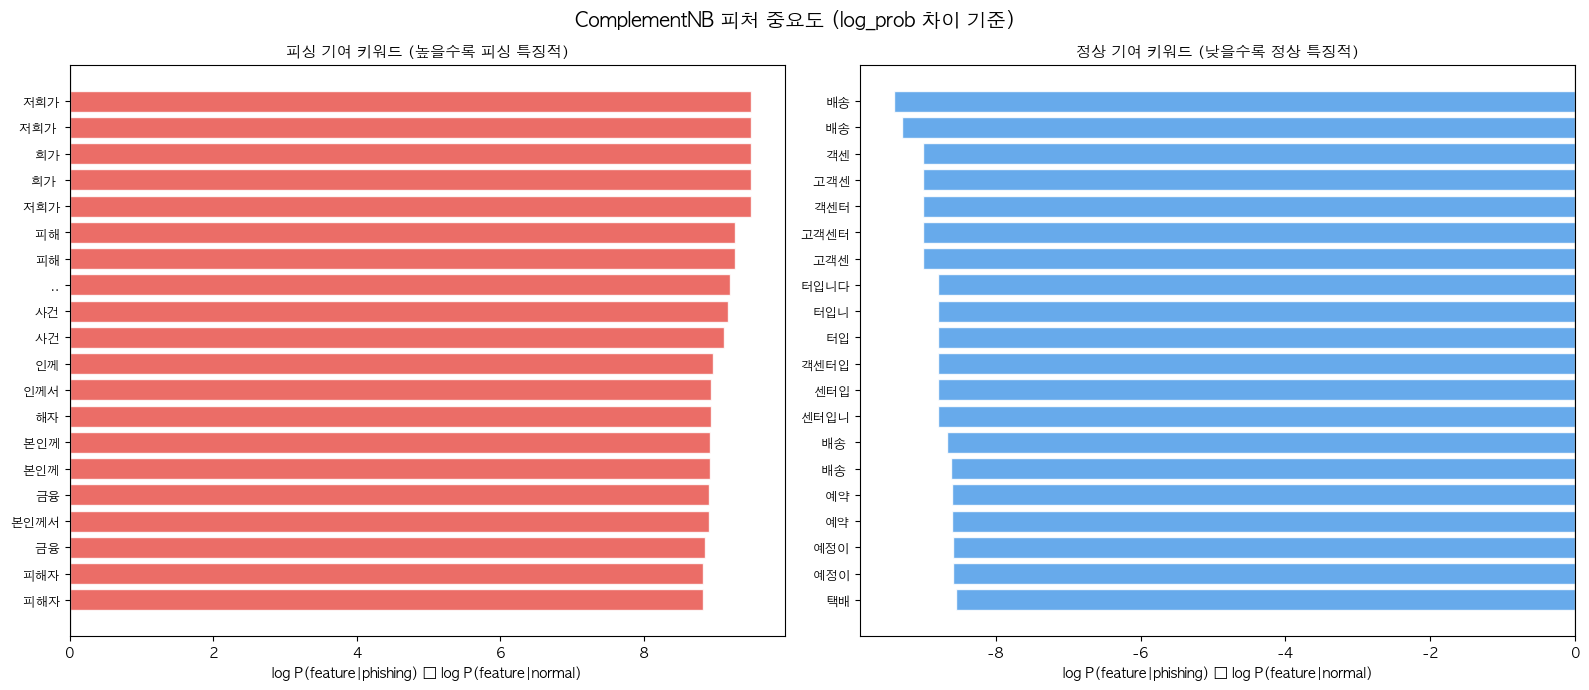

[Save] feature_importance.png


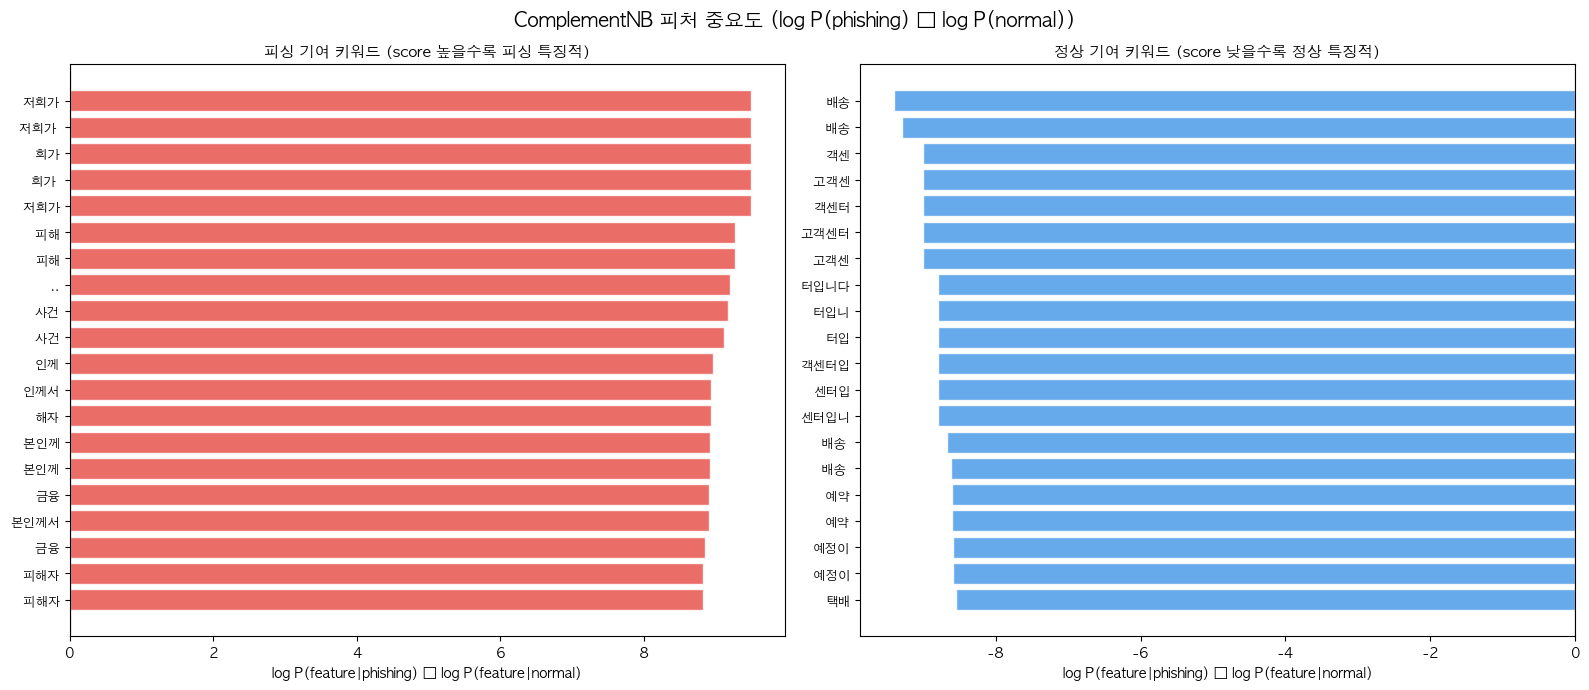

[Save] feature_importance.png

[ 종합 검증 결과 ]

✅ 누수 없음 + 텍스트 n-gram 패턴 기반 학습 확인
   Recall(phishing)=0.9912 | Recall(normal)=1.0000

→ 성능이 실제 데이터 패턴을 학습한 결과로 판단됨.
   단, 실제 운영 환경에서 새로운 유형의 보이스피싱 등장 시 재학습 필요.


In [13]:
# ============================================================
# [검증 셀 0] 의존성 임포트 및 경로 설정
# VoiceData.ipynb에 셀 단위로 복사해서 사용
# ============================================================

import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

# ── 한글 폰트 (macOS) ────────────────────────────────────────
plt.rcParams["font.family"]        = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 경로 ─────────────────────────────────────────────────────
MODEL_PATH      = Path("../VoiceModel/voice_model_artifact.pkl")
VECTORIZER_PATH = Path("../VoiceModel/voice_vectorizer.pkl")
DATA_PATH       = Path("../Data/CallData/metadata_clean.csv")

# ── 아티팩트 로드 ─────────────────────────────────────────────
artifact   = joblib.load(MODEL_PATH)
vectorizer = joblib.load(VECTORIZER_PATH)

model           = artifact["model"]
threshold       = artifact["threshold"]
classes         = artifact["classes"]
vectorizer_type = artifact["vectorizer_type"]
phishing_idx    = classes.index("phishing")

# ── 데이터 로드 ───────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df_train = df[df["split"] == "train"].reset_index(drop=True)
df_val   = df[df["split"] == "validation"].reset_index(drop=True)
df_test  = df[df["split"] == "test"].reset_index(drop=True)

print(f"모델 로드 완료 | threshold={threshold} | vec={vectorizer_type}")
print(f"Train={len(df_train)} | Val={len(df_val)} | Test={len(df_test)}")


# ============================================================
# [검증 셀 1] 누수 검증 A — parent_call_id 기준
# 같은 통화(parent_call_id)의 세그먼트가 train/test에 동시 존재하면 누수
# ============================================================

train_calls = set(df_train["parent_call_id"])
val_calls   = set(df_val["parent_call_id"])
test_calls  = set(df_test["parent_call_id"])

train_test_overlap = train_calls & test_calls
train_val_overlap  = train_calls & val_calls
val_test_overlap   = val_calls   & test_calls

print("=== [누수 검증 A] parent_call_id 기준 통화 중복 ===\n")
print(f"Train ∩ Test  겹치는 통화 수: {len(train_test_overlap)}개")
print(f"Train ∩ Val   겹치는 통화 수: {len(train_val_overlap)}개")
print(f"Val   ∩ Test  겹치는 통화 수: {len(val_test_overlap)}개")

if train_test_overlap:
    print(f"\n[WARNING] Train-Test 누수 {len(train_test_overlap)}개 통화 발견!")
    # 누수 통화에 속한 샘플 확인
    leak_test_samples = df_test[df_test["parent_call_id"].isin(train_test_overlap)]
    print(f"  → test에 누수된 샘플 {len(leak_test_samples)}건:")
    print(leak_test_samples[["sample_id", "parent_call_id", "label", "text_clean"]].head(3).to_string())
else:
    print("\n[OK] Train-Test 간 통화 중복 없음 — parent_call_id 누수 없음")

if train_val_overlap:
    print(f"\n[WARNING] Train-Val 누수 {len(train_val_overlap)}개 통화 발견!")
else:
    print("[OK] Train-Val 간 통화 중복 없음")


# ============================================================
# [검증 셀 2] 누수 검증 B — text_clean 기준
# 전처리 후 동일 텍스트가 train/test 양쪽에 존재하면 누수
# ============================================================

print("=== [누수 검증 B] text_clean 기준 텍스트 중복 ===\n")

train_texts = set(df_train["text_clean"])
val_texts   = set(df_val["text_clean"])
test_texts  = set(df_test["text_clean"])

tt_text_overlap = train_texts & test_texts
tv_text_overlap = train_texts & val_texts
vt_text_overlap = val_texts   & test_texts

print(f"Train ∩ Test  겹치는 텍스트: {len(tt_text_overlap)}건")
print(f"Train ∩ Val   겹치는 텍스트: {len(tv_text_overlap)}건")
print(f"Val   ∩ Test  겹치는 텍스트: {len(vt_text_overlap)}건")

if tt_text_overlap:
    print(f"\n[WARNING] Train-Test 텍스트 누수 {len(tt_text_overlap)}건 발견!")
    for t in list(tt_text_overlap)[:3]:
        print(f"  → {t[:80]}...")
else:
    print("\n[OK] Train-Test 간 텍스트 중복 없음 — text_clean 누수 없음")


# ============================================================
# [검증 셀 3] 성능이 진짜인지 확인 — 구조적 피처 제거 후 텍스트만으로 재평가
# 구조적 피처(수사기관/대출 키워드)에만 의존한 게 아닌지 확인
# 텍스트 피처 단독 성능 vs 전체 피처 성능 비교
# ============================================================

# 구조적 피처 추출 함수 (train_voice.py와 동일)
_RE_URGENCY    = re.compile(r"지금\s*바로|즉시|긴급|당장|오늘\s*안에|시간이\s*없")
_RE_AUTHORITY  = re.compile(r"검찰|경찰|금감원|금융감독원|국세청|법원|수사관|형사")
_RE_MONEY      = re.compile(r"대출|이자|원금|계좌|송금|이체|입금|출금|돈")
_RE_PERSONAL   = re.compile(r"주민\s*번호|계좌\s*번호|비밀\s*번호|카드\s*번호|개인\s*정보")
_RE_THREAT     = re.compile(r"체포|구속|압수|수색|처벌|벌금|기소|고소|고발")
_RE_SAFE_ACCT  = re.compile(r"안전\s*계좌|보호\s*계좌|임시\s*계좌|자금\s*보호")
_RE_INSTALL    = re.compile(r"앱\s*설치|다운로드|원격|팀뷰어|애니데스크")
_RE_LONG_TEXT  = re.compile(r".{200,}")

def _extract_struct(texts: pd.Series) -> np.ndarray:
    return np.column_stack([
        texts.str.contains(_RE_URGENCY,   regex=True).astype(int).values,
        texts.str.contains(_RE_AUTHORITY, regex=True).astype(int).values,
        texts.str.contains(_RE_MONEY,     regex=True).astype(int).values,
        texts.str.contains(_RE_PERSONAL,  regex=True).astype(int).values,
        texts.str.contains(_RE_THREAT,    regex=True).astype(int).values,
        texts.str.contains(_RE_SAFE_ACCT, regex=True).astype(int).values,
        texts.str.contains(_RE_INSTALL,   regex=True).astype(int).values,
        texts.str.contains(_RE_LONG_TEXT, regex=True).astype(int).values,
    ])

def _build_X(texts: pd.Series, include_struct: bool = True):
    """
    텍스트 피처 + 구조적 피처 결합.
    include_struct=False 시 구조적 피처를 0으로 채워 shape 유지.
    → 모델 입력 차원(8008) 고정, 구조적 피처 기여도만 제거.
    """
    X_text   = vectorizer.transform(texts)
    n_struct = 8  # 구조적 피처 수

    if include_struct:
        X_struct = csr_matrix(_extract_struct(texts))
    else:
        # 구조적 피처를 0으로 채움 — shape은 유지하되 기여도 제거
        X_struct = csr_matrix(np.zeros((len(texts), n_struct), dtype=np.float32))

    return hstack([X_text, X_struct])

def _evaluate(X, y_true: pd.Series, label: str) -> dict:
    """threshold 적용 후 Recall(phishing), Recall(normal) 반환."""
    y_prob = model.predict_proba(X)[:, phishing_idx]
    y_pred = np.where(y_prob >= threshold, "phishing", "normal")
    cm     = confusion_matrix(y_true, y_pred, labels=["normal", "phishing"])
    rec_p  = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0.0
    rec_n  = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0.0
    print(f"\n[{label}]")
    print(classification_report(y_true, y_pred, target_names=["normal", "phishing"]))
    return {"rec_p": rec_p, "rec_n": rec_n}

print("=== [성능 검증] 텍스트 단독 vs 전체 피처 비교 (test 세트) ===\n")

# 전체 피처 (텍스트 + 구조적 피처)
r_full  = _evaluate(_build_X(df_test["text_clean"], include_struct=True),
                    df_test["label"], "전체 피처 (텍스트 + 구조적)")

# 텍스트 피처만
r_text  = _evaluate(_build_X(df_test["text_clean"], include_struct=False),
                    df_test["label"], "텍스트 피처만 (구조적 피처 제외)")

print(f"\n구조적 피처 기여도:")
print(f"  Recall(phishing) 차이: {r_full['rec_p'] - r_text['rec_p']:+.4f}")
print(f"  Recall(normal)   차이: {r_full['rec_n'] - r_text['rec_n']:+.4f}")
print("→ 차이가 크면 구조적 피처 의존도가 높음 (키워드에만 의존한 가능성)")
print("→ 차이가 작으면 텍스트 자체의 n-gram 패턴으로 학습된 것")


# ============================================================
# [검증 셀 4] 통화 유형별(call_type) 성능 분리 확인
# ============================================================

print("=== [유형별 성능] call_type별 Recall(phishing) 분리 확인 ===\n")

# metadata_clean.csv에는 call_type 제외됨 → 원본 metadata.csv에서 가져옴
METADATA_RAW_PATH = Path("../Data/CallData/metadata.csv")
df_meta = pd.read_csv(METADATA_RAW_PATH)

df_test_with_type = df_test.merge(
    df_meta[["sample_id", "call_type"]],
    on="sample_id",
    how="left",
)

# call_type 병합 결과 검증
missing_call_type = df_test_with_type["call_type"].isna().sum()
if missing_call_type > 0:
    print(f"[WARNING] call_type 매핑 실패 {missing_call_type}건 — sample_id 불일치 확인 필요")

X_test_full = _build_X(df_test["text_clean"], include_struct=True)
y_prob_test = model.predict_proba(X_test_full)[:, phishing_idx]

df_test_with_type["y_pred"]  = np.where(y_prob_test >= threshold, "phishing", "normal")
df_test_with_type["y_prob"]  = y_prob_test
df_test_with_type["correct"] = (
    df_test_with_type["y_pred"] == df_test_with_type["label"]
)

# 피싱 샘플 유형별 Recall
df_phishing_test = df_test_with_type[df_test_with_type["label"] == "phishing"]
print("피싱 유형별 탐지율(Recall):")
for call_type, grp in df_phishing_test.groupby("call_type"):
    recall = grp["correct"].mean()
    print(f"  {call_type:15}: {recall:.4f} ({len(grp)}건)")

# 정상 샘플 유형별 정확도
df_normal_test = df_test_with_type[df_test_with_type["label"] == "normal"]
print("\n정상 유형별 정확도:")
for call_type, grp in df_normal_test.groupby("call_type"):
    acc = grp["correct"].mean()
    print(f"  {call_type:15}: {acc:.4f} ({len(grp)}건)")


# ============================================================
# [검증 셀 5] 피처 중요도 분석
# ComplementNB는 LinearExplainer 미지원
# → feature_log_prob_ 기반 클래스별 피처 중요도로 대체
#   (phishing log_prob - normal log_prob = 해당 n-gram이 피싱에 얼마나 특징적인지)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ── 피처명 구성 (텍스트 n-gram + 구조적 피처 8개) ──────────────
feature_names = list(vectorizer.get_feature_names_out()) + [
    "has_urgency", "has_authority", "has_money", "has_personal",
    "has_threat",  "has_safe_acct", "has_install", "is_long_text",
]

# ── base_estimator 추출 ─────────────────────────────────────
# CalibratedClassifierCV → 내부 calibrated_classifiers_[0].estimator
base_nb = model.calibrated_classifiers_[0].estimator
# ComplementNB.feature_log_prob_: shape (n_classes, n_features)
# classes_ 순서: ['normal', 'phishing']
normal_idx_nb   = list(base_nb.classes_).index("normal")
phishing_idx_nb = list(base_nb.classes_).index("phishing")

# 구조적 피처 8개는 ComplementNB 학습에 포함됐으므로
# feature_log_prob_ 열 수 = 텍스트 피처 수 + 8
log_prob_normal   = base_nb.feature_log_prob_[normal_idx_nb]
log_prob_phishing = base_nb.feature_log_prob_[phishing_idx_nb]

# 피싱 특징도 = P(feature|phishing) - P(feature|normal) 로그 차이
# 값이 클수록 피싱에서 더 자주 등장하는 패턴
phishing_score = log_prob_phishing - log_prob_normal

# ── 상위/하위 20개 추출 ──────────────────────────────────────
n_top = 20
top_phishing_idx = np.argsort(phishing_score)[::-1][:n_top]  # 피싱 기여
top_normal_idx   = np.argsort(phishing_score)[:n_top]         # 정상 기여

print("=== 피싱 판단 기여 상위 20 키워드 (log_prob 차이 기준) ===\n")
for rank, idx in enumerate(top_phishing_idx, 1):
    print(f"  {rank:2}. '{feature_names[idx]}'  (score={phishing_score[idx]:.4f})")

print("\n=== 정상 판단 기여 상위 20 키워드 ===\n")
for rank, idx in enumerate(top_normal_idx, 1):
    print(f"  {rank:2}. '{feature_names[idx]}'  (score={phishing_score[idx]:.4f})")

# ── 시각화 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ComplementNB 피처 중요도 (log_prob 차이 기준)", fontsize=14, fontweight="bold")

# 피싱 기여 키워드
p_names  = [feature_names[i] for i in top_phishing_idx]
p_scores = [phishing_score[i] for i in top_phishing_idx]
axes[0].barh(range(n_top), p_scores[::-1], color="#E8534C", alpha=0.85, edgecolor="white")
axes[0].set_yticks(range(n_top))
axes[0].set_yticklabels(p_names[::-1], fontsize=9)
axes[0].set_title("피싱 기여 키워드 (높을수록 피싱 특징적)", fontsize=11)
axes[0].set_xlabel("log P(feature|phishing) − log P(feature|normal)")
axes[0].axvline(0, color="black", linewidth=0.8)

# 정상 기여 키워드
n_names  = [feature_names[i] for i in top_normal_idx]
n_scores = [phishing_score[i] for i in top_normal_idx]
axes[1].barh(range(n_top), n_scores[::-1], color="#4C9BE8", alpha=0.85, edgecolor="white")
axes[1].set_yticks(range(n_top))
axes[1].set_yticklabels(n_names[::-1], fontsize=9)
axes[1].set_title("정상 기여 키워드 (낮을수록 정상 특징적)", fontsize=11)
axes[1].set_xlabel("log P(feature|phishing) − log P(feature|normal)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("../VoiceModel/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Save] feature_importance.png")
# ============================================================
# [검증 셀 6] 피처 중요도 시각화
# 셀 5의 feature_log_prob_ 차이(phishing_score) 기반으로 시각화
# mean_shap_phishing 참조 제거 → p_scores / n_scores 사용
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "ComplementNB 피처 중요도 (log P(phishing) − log P(normal))",
    fontsize=14, fontweight="bold",
)

# ── 피싱 기여 키워드 (양의 차이, 피싱에서 자주 등장) ─────────────
p_names  = [feature_names[i] for i in top_phishing_idx]
p_scores = [phishing_score[i] for i in top_phishing_idx]

axes[0].barh(
    range(n_top), p_scores[::-1],
    color="#E8534C", alpha=0.85, edgecolor="white",
)
axes[0].set_yticks(range(n_top))
axes[0].set_yticklabels(p_names[::-1], fontsize=9)
axes[0].set_title("피싱 기여 키워드 (score 높을수록 피싱 특징적)", fontsize=11)
axes[0].set_xlabel("log P(feature|phishing) − log P(feature|normal)")
axes[0].axvline(0, color="black", linewidth=0.8)

# ── 정상 기여 키워드 (음의 차이, 정상에서 자주 등장) ─────────────
n_names  = [feature_names[i] for i in top_normal_idx]
n_scores = [phishing_score[i] for i in top_normal_idx]

axes[1].barh(
    range(n_top), n_scores[::-1],
    color="#4C9BE8", alpha=0.85, edgecolor="white",
)
axes[1].set_yticks(range(n_top))
axes[1].set_yticklabels(n_names[::-1], fontsize=9)
axes[1].set_title("정상 기여 키워드 (score 낮을수록 정상 특징적)", fontsize=11)
axes[1].set_xlabel("log P(feature|phishing) − log P(feature|normal)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("../VoiceModel/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Save] feature_importance.png")


# ============================================================
# [검증 셀 7] 최종 종합 판단
# 위 검증 결과를 바탕으로 성능이 진짜인지 자동 판단
# ============================================================

print("\n" + "="*60)
print("[ 종합 검증 결과 ]")
print("="*60)

issues = []

# 1. 누수 확인
if train_test_overlap:
    issues.append(f"[누수 A] Train-Test 통화 중복 {len(train_test_overlap)}개")
if tt_text_overlap:
    issues.append(f"[누수 B] Train-Test 텍스트 중복 {len(tt_text_overlap)}건")

# 2. 구조적 피처 의존도 확인
struct_contribution_p = r_full["rec_p"] - r_text["rec_p"]
struct_contribution_n = r_full["rec_n"] - r_text["rec_n"]
if abs(struct_contribution_p) > 0.1:
    issues.append(
        f"[피처 의존] 구조적 피처 제거 시 Recall(phishing) {struct_contribution_p:+.4f} 변화 "
        "— 키워드 패턴에 과의존 가능성"
    )

if issues:
    print("\n⚠️  발견된 문제:")
    for issue in issues:
        print(f"   {issue}")
    print("\n→ 성능이 과대평가됐을 가능성 있음. 위 문제 해결 후 재학습 권장.")
else:
    print("\n✅ 누수 없음 + 텍스트 n-gram 패턴 기반 학습 확인")
    print(f"   Recall(phishing)={r_full['rec_p']:.4f} | Recall(normal)={r_full['rec_n']:.4f}")
    print("\n→ 성능이 실제 데이터 패턴을 학습한 결과로 판단됨.")
    print("   단, 실제 운영 환경에서 새로운 유형의 보이스피싱 등장 시 재학습 필요.")